# Exp 18 — CLIP MLP: Octopus Presence Classifier

Binary classification: **visible** (octopus present) vs **hidden** (not visible).  
Frozen CLIP ViT-B/32 features → MLP head (512 → 256 → 64 → 2) with dropout.  
Replaces the single linear layer from exp17.

In [1]:
%pip install -q openai-clip setuptools packaging scikit-learn matplotlib pillow torch torchvision tqdm ipywidgets wandb


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /Users/siddharthraj/Documents/my-projects/sentiment-analysis/venv/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import packaging.version, packaging.specifiers
import pkg_resources
pkg_resources.packaging = packaging

import os
import clip
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from torch.utils.data import DataLoader, TensorDataset

PROJECT    = Path(".").resolve().parent
MANIFEST   = PROJECT / "data" / "frames" / "manifest.csv"
CACHE_PATH = PROJECT / "data" / "frames" / "clip_features.npz"
CKPT_PATH  = PROJECT / "weights" / "clip_mlp_best.pt"

EPOCHS     = 50
BATCH_SIZE = 64
LR         = 1e-3
DROPOUT    = 0.3
SEED       = 42

torch.manual_seed(SEED)
device = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()         else
    "cpu"
)
print(f"Device: {device}")

/var/folders/4x/8gdbr2c547b7s8k94zw4rwmh0000gn/T/ipykernel_90497/4159751184.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Device: mps


## 1 — Load manifest

In [3]:
df = pd.read_csv(MANIFEST)
# exclude augmented frames — train on real reviewed frames only
df = df[~df["path"].str.contains("hidden_aug")].reset_index(drop=True)
df["abs_path"] = df["path"].apply(lambda p: PROJECT / p)
df = df[df["abs_path"].apply(lambda p: p.exists())].reset_index(drop=True)

label_map = {"visible": 1, "hidden": 0}
df["y"] = df["label"].map(label_map)

print(f"{len(df)} frames")
print(df["label"].value_counts().to_string())

7952 frames
label
hidden     3982
visible    3970


## 2 — Extract CLIP features (cached after first run)

In [4]:
clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print("CLIP ViT-B/32 loaded — feature dim: 512")

CLIP ViT-B/32 loaded — feature dim: 512


In [5]:
# letterbox: resize longest side to 224 + pad to 224x224 (no crop -> full frame kept)
def letterbox(img, size=224, fill=(128, 128, 128)):
    w, h = img.size
    s = size / max(w, h)
    nw, nh = max(1, round(w * s)), max(1, round(h * s))
    img = img.resize((nw, nh), Image.BICUBIC)
    canvas = Image.new("RGB", (size, size), fill)
    canvas.paste(img, ((size - nw) // 2, (size - nh) // 2))
    return canvas


def extract_features(paths):
    feats = []
    for i in tqdm(range(0, len(paths), BATCH_SIZE), desc="CLIP encode"):
        batch_paths = paths[i : i + BATCH_SIZE]
        imgs = []
        for p in batch_paths:
            try:
                imgs.append(preprocess(letterbox(Image.open(p).convert("RGB"))))
            except Exception:
                imgs.append(torch.zeros(3, 224, 224))
        batch = torch.stack(imgs).to(device)
        with torch.no_grad():
            f = clip_model.encode_image(batch).float()
            f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu().numpy())
    return np.vstack(feats)


current_paths = [str(p) for p in df["abs_path"]]

if CACHE_PATH.exists():
    cache = np.load(CACHE_PATH, allow_pickle=True)
    if list(cache["paths"]) == current_paths:
        features = cache["features"]
        print(f"Cache hit — {len(features)} features loaded")
    else:
        print("Manifest changed — re-extracting ...")
        features = extract_features(df["abs_path"].tolist())
        np.savez(CACHE_PATH, features=features, paths=current_paths)
else:
    features = extract_features(df["abs_path"].tolist())
    np.savez(CACHE_PATH, features=features, paths=current_paths)
    print(f"Features cached → {CACHE_PATH}")

print(f"Feature matrix: {features.shape}  (n_frames × clip_dim)")

CLIP encode:   0%|          | 0/125 [00:00<?, ?it/s]

Features cached → /Users/siddharthraj/Documents/my-projects/sentiment-analysis/data/frames/clip_features.npz
Feature matrix: (7952, 512)  (n_frames × clip_dim)


## 3 — Train / test split (80 / 20, stratified)

In [6]:
X = features.astype(np.float32)
y = df["y"].values.astype(np.int64)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(df)),
    test_size=0.2, random_state=SEED, stratify=y,
)

n_vis = y_train.sum()
n_hid = (y_train == 0).sum()
class_weights = torch.tensor(
    [len(y_train) / (2 * n_hid), len(y_train) / (2 * n_vis)],
    dtype=torch.float32
).to(device)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Train — visible: {n_vis}  hidden: {n_hid}")
print(f"Class weights → hidden: {class_weights[0]:.2f}  visible: {class_weights[1]:.2f}")

Train: 6361  |  Test: 1591
Train — visible: 3176  hidden: 3185
Class weights → hidden: 1.00  visible: 1.00


In [7]:
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

## 4 — Define model: MLP on top of frozen CLIP

In [8]:
feat_dim = X.shape[1]  # 512 for ViT-B/32

classifier = nn.Sequential(
    nn.Linear(feat_dim, 256),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(64, 2),
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in classifier.parameters())
print(f"Model: MLP({feat_dim} → 256 → 64 → 2)  params: {total_params:,}")

Model: MLP(512 → 256 → 64 → 2)  params: 147,906


## 5 — W&B init

In [9]:
WANDB_API_KEY = os.environ.get("WANDB_API_KEY")  # set via: export WANDB_API_KEY=...
wandb.login(key=WANDB_API_KEY)

True

In [10]:
wandb.init(
    project="nity-octopus-detector",
    name="clip-mlp",
    config={
        "model":      "CLIP ViT-B/32 + MLP",
        "epochs":     EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr":         LR,
        "dropout":    DROPOUT,
        "optimizer":  "Adam",
        "scheduler":  "CosineAnnealingLR",
        "feat_dim":   feat_dim,
        "train_size": len(X_train),
        "test_size":  len(X_test),
        "n_visible":  int(n_vis),
        "n_hidden":   int(n_hid),
    },
)

## 6 — Train

In [11]:
def run_epoch(loader, train=True):
    classifier.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = classifier(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total


best_val_acc = 0.0
history      = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    vl_loss, vl_acc = run_epoch(test_dl,  train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    wandb.log({
        "epoch":      epoch,
        "train/loss": tr_loss,
        "val/loss":   vl_loss,
        "train/acc":  tr_acc,
        "val/acc":    vl_acc,
        "lr":         scheduler.get_last_lr()[0],
    })

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(classifier.state_dict(), CKPT_PATH)

print(f"\nBest val acc: {best_val_acc:.1%}  (checkpoint → {CKPT_PATH.name})")

Training:   0%|          | 0/50 [00:00<?, ?it/s]


Best val acc: 96.3%  (checkpoint → clip_mlp_best.pt)


## 7 — Training curves

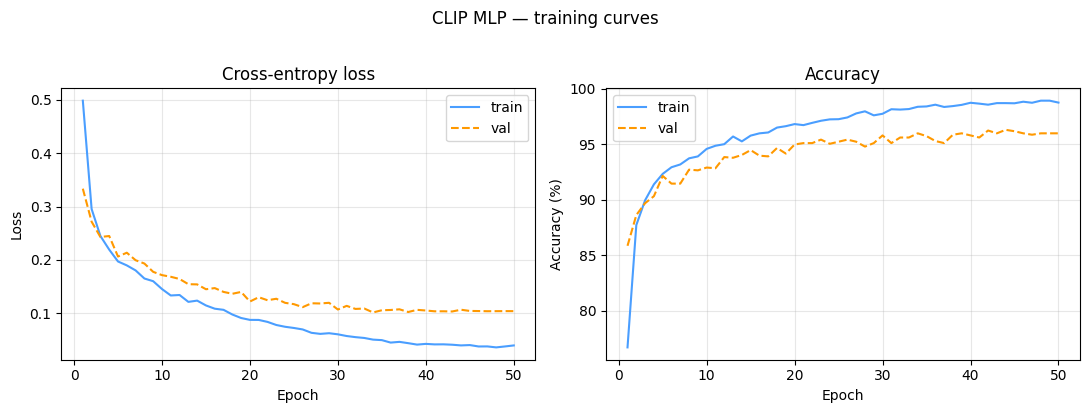

In [12]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs, history["train_loss"], label="train", color="#4a9eff")
ax1.plot(epochs, history["val_loss"],   label="val",   color="#f90", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Cross-entropy loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, [a*100 for a in history["train_acc"]], label="train", color="#4a9eff")
ax2.plot(epochs, [a*100 for a in history["val_acc"]],   label="val",   color="#f90", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.set_title("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("CLIP MLP — training curves", y=1.02)
plt.tight_layout()
curve_path = PROJECT / "data" / "frames" / "training_curves_mlp.png"
plt.savefig(curve_path, dpi=120, bbox_inches="tight")
wandb.log({"charts/loss_curve": wandb.Image(str(curve_path))})
plt.show()

## 8 — Evaluate on test set

In [13]:
classifier.load_state_dict(torch.load(CKPT_PATH, map_location=device))
classifier.eval()

all_preds, all_probs, all_gt = [], [], []
with torch.no_grad():
    for xb, yb in test_dl:
        logits = classifier(xb.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
        all_gt.extend(yb.tolist())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_gt    = np.array(all_gt)

acc = accuracy_score(all_gt, all_preds)
print(f"Test accuracy: {acc:.1%}\n")
print(classification_report(all_gt, all_preds, target_names=["hidden", "visible"]))

wandb.log({"test/accuracy": acc})

Test accuracy: 96.3%

              precision    recall  f1-score   support

      hidden       0.96      0.97      0.96       797
     visible       0.97      0.95      0.96       794

    accuracy                           0.96      1591
   macro avg       0.96      0.96      0.96      1591
weighted avg       0.96      0.96      0.96      1591



## 9 — Confusion matrix

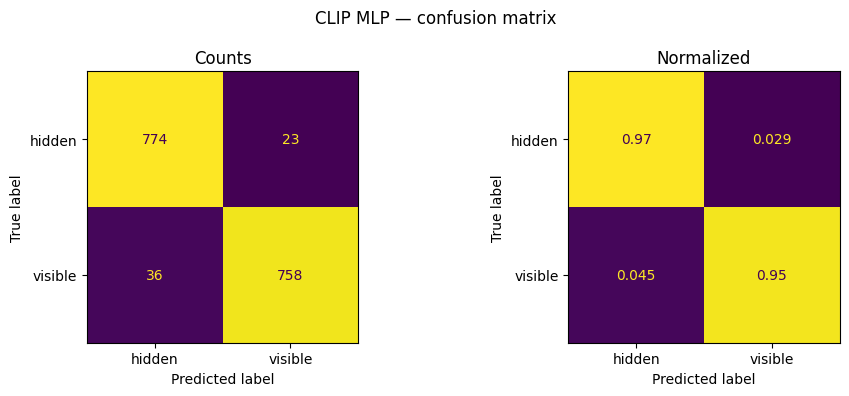

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, normalize, title in zip(axes, [None, "true"], ["Counts", "Normalized"]):
    cm = confusion_matrix(all_gt, all_preds, normalize=normalize)
    disp = ConfusionMatrixDisplay(cm, display_labels=["hidden", "visible"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.suptitle("CLIP MLP — confusion matrix")
plt.tight_layout()
wandb.log({"charts/confusion_matrix": wandb.Image(fig)})
plt.show()

## 10 — Save checkpoint & finish

In [15]:
torch.save({
    "state_dict": classifier.state_dict(),
    "feat_dim":   feat_dim,
    "label_map":  label_map,
    "clip_model": "ViT-B/32",
    "arch":       "mlp_256_64",
    "test_acc":   float(acc),
}, CKPT_PATH)

artifact = wandb.Artifact("clip-mlp", type="model")
artifact.add_file(str(CKPT_PATH))
wandb.log_artifact(artifact)
wandb.finish()

print(f"Done. Best val acc: {best_val_acc:.1%}")
print(f"Checkpoint: {CKPT_PATH}")

Done. Best val acc: 96.3%
Checkpoint: /Users/siddharthraj/Documents/my-projects/sentiment-analysis/weights/clip_mlp_best.pt
